# **Day - 8 | Digit Recognition using RANDOM FOREST**

# *Importing Basic Library*

In [1]:
import pandas as pd
import numpy as np

### *Access Google Drive contents*

### *Load Dataset*

In [3]:
dataset = pd.read_csv('digit.csv')

### *Summarize Dataset*

In [4]:
print(dataset.shape)
print(dataset.head(5))

(2290, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
1       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
3       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
4       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel780  pixel781  pixel782  pixel783  
0       0.0       

### *Segregate Dataset into X(Input/IndependentVariable) & Y(Output/DependentVariable)*

In [5]:
X = dataset.iloc[:,1:]
print(X)
print(X.shape)

      pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0          0       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          0       0       0       0       0       0       0       0       0   
3          0       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
2285       0       0       0       0       0       0       0       0       0   
2286       0       0       0       0       0       0       0       0       0   
2287       0       0       0       0       0       0       0       0       0   
2288       0       0       0       0       0       0       0       0       0   
2289       0       0       0       0       0       0       0       0       0   

      pixel9  ...  pixel774  pixel775  

In [6]:
Y = dataset.iloc[:,0]
print(Y)
print(Y.shape)

0       1
1       0
2       1
3       4
4       0
       ..
2285    1
2286    0
2287    2
2288    2
2289    7
Name: label, Length: 2290, dtype: int64
(2290,)


### *Splitting Dataset into Test & Train*

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

### *Training*

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=0
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=0)

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[59  0  0  0  0  0  2  0  1  0]
 [ 0 66  0  0  1  0  1  0  0  0]
 [ 0  2 64  0  0  0  0  1  0  0]
 [ 2  1  2 46  0  3  1  0  3  2]
 [ 0  0  0  0 47  0  0  1  0  2]
 [ 0  2  1  3  0 48  0  0  0  0]
 [ 1  0  1  0  0  0 48  0  1  0]
 [ 0  2  2  0  1  0  0 43  0  6]
 [ 0  1  0  1  1  0  0  0 48  5]
 [ 0  0  0  0  2  0  0  1  0 48]]


### *Model Accuracy*

In [11]:
from sklearn.metrics import accuracy_score
print("Accuracy of the Model: {0}%".format(accuracy_score(y_test, y_pred)*100))

Accuracy of the Model: 90.22687609075044%


In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        62
           1       0.89      0.97      0.93        68
           2       0.91      0.96      0.93        67
           3       0.92      0.77      0.84        60
           4       0.90      0.94      0.92        50
           5       0.94      0.89      0.91        54
           6       0.92      0.94      0.93        51
           7       0.93      0.80      0.86        54
           8       0.91      0.86      0.88        56
           9       0.76      0.94      0.84        51

    accuracy                           0.90       573
   macro avg       0.90      0.90      0.90       573
weighted avg       0.91      0.90      0.90       573



Actual Digit: 5
Predicted Digit: 5


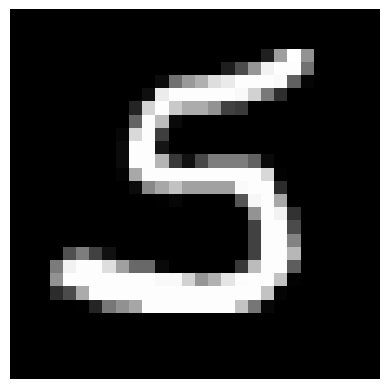

In [14]:
import matplotlib.pyplot as plt
index = 0 # Changed from 2000 to a valid index
print("Actual Digit:", y_test.iloc[index])
print("Predicted Digit:", model.predict(X_test)[index])
plt.axis('off')
plt.imshow(X_test.iloc[index].values.reshape((28,28)),cmap='gray')